In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bliss import *

In [2]:
import pandas as pd
from io import StringIO

data = """spectrum,element,line,lambda_ref_A,v_doppler_km_s,lambda_obs_A,energy_obs_keV,sigma_lambda_A_fixed,sigma_energy_keV,flux_1e_minus5_ph_s_cm2,flux_err_minus,flux_err_plus,bayesian_blocks_alpha,detected_by_bayesian_blocks,flux_note
high-hardness,Si,Si XIV Lyα,6.18224,-170.0,6.178734,2.006628,0.003,0.000974,5.9,2.2,2.3,>=3.3,True,
high-hardness,Si,Si XIII r,6.64795,-170.0,6.644180,1.866057,0.003,0.000843,4.5,2.0,2.2,no,False,
high-hardness,Si,Si XIII f,6.74029,-170.0,6.736468,1.840493,0.003,0.000820,6.3,2.2,2.3,>=3.3,True,
high-hardness,Si,Si VIII Kα,7.00076,-1450.0,6.966900,1.779618,0.003,0.000766,3.8,1.7,1.7,no,False,
high-hardness,Si,Si VII Kα,7.05787,-1450.0,7.023733,1.765218,0.003,0.000754,3.5,1.8,1.8,no,False,
high-hardness,Si,Si II–VI Kα blend,7.11722,-680.0,7.101076,1.745992,0.003,0.000738,4.6,1.8,1.9,>=3.3,True,
low-hardness,Si,Si XIII f,6.74029,-90.0,6.738267,1.840001,0.003,0.000819,19.0,3.0,3.0,>=8.5,True,
high-hardness,Mg,Mg XII Lyα,8.42101,140.0,8.424943,1.471633,0.003,0.000524,4.2,1.7,1.9,5.4,True,
high-hardness,Mg,Mg XI r,9.16896,140.0,9.173242,1.351585,0.003,0.000442,2.1,,,5.4,True,derived from triplet ratios
high-hardness,Mg,Mg XI i,9.22990,140.0,9.234210,1.342662,0.003,0.000436,1.8,0.7,0.5,5.4,True,
high-hardness,Mg,Mg XI f,9.31455,140.0,9.318900,1.330460,0.003,0.000428,2.7,,,5.4,True,derived from triplet ratios
low-hardness,Mg,Mg XI r,9.16896,-130.0,9.164984,1.352803,0.003,0.000443,4.9,1.9,2.0,>7,True,
low-hardness,Mg,Mg XI i,9.22990,-130.0,9.225898,1.343871,0.003,0.000437,5.6,2.0,2.1,>7,True,
low-hardness,Mg,Mg XI f,9.31455,-130.0,9.310511,1.331658,0.003,0.000429,5.4,2.1,2.2,>7,True,
high-hardness,Ne,Ne X Lyα,12.1338,-220.0,12.124896,1.022559,0.003,0.000253,2.1,1.2,1.7,3.4,True,
high-hardness,Ne,Ne X Lyβ,10.23887,-220.0,10.231356,1.211806,0.003,0.000355,2.5,1.2,1.5,2,True,
high-hardness,Ne,Ne IX r,13.4476,-220.0,13.437732,0.922657,0.003,0.000206,0.7,,,2.5,True,derived from triplet ratios
high-hardness,Ne,Ne IX i,13.5520,-220.0,13.542055,0.915549,0.003,0.000203,3.0,1.6,2.3,2.5,True,
high-hardness,Ne,Ne IX f,13.6993,-220.0,13.689247,0.905705,0.003,0.000198,2.4,,,2.5,True,derived from triplet ratios
low-hardness,Ne,Ne X Lyα,12.1338,40.0,12.135419,1.021672,0.003,0.000253,4.3,1.7,1.9,4.6,True,
low-hardness,Ne,Ne IX r,13.4476,40.0,13.449394,0.921857,0.003,0.000206,2.8,1.8,1.7,5,True,
low-hardness,Ne,Ne IX i,13.5520,40.0,13.553808,0.914755,0.003,0.000202,4.3,1.6,2.6,5,True,
low-hardness,Ne,Ne IX f,13.6993,40.0,13.701128,0.904920,0.003,0.000198,3.7,2.1,2.0,5,True,
high-hardness,Fe,Fe Kα,,,1.937500,6.399184,0.003,0.009908,184.0,23.0,23.0,>=10,True,Table 8 gives fitted wavelength directly; flux converted from 10^-3 to 10^-5
high-hardness,Fe,Fe Kβ,,,1.752000,7.076724,0.003,0.012118,53.0,30.0,30.0,2.2,True,Table 8 gives fitted wavelength directly; flux converted from 10^-3 to 10^-5
low-hardness,Fe,Fe Kα,,,1.936900,6.401167,0.003,0.009915,243.0,18.0,18.0,>=10,True,Table 8 gives fitted wavelength directly; flux converted from 10^-3 to 10^-5
low-hardness,Fe,Fe Kβ,,,1.758000,7.052571,0.003,0.012035,51.0,23.0,23.0,3,True,Table 8 gives fitted wavelength directly; flux converted from 10^-3 to 10^-5
"""

df_grinberg = pd.read_csv(StringIO(data))

high = df_grinberg[df_grinberg["spectrum"] == "high-hardness"].reset_index(drop=True)
low = df_grinberg[df_grinberg["spectrum"] == "low-hardness"].reset_index(drop=True)

In [3]:
def sort_spectrum_by_energy(energy, values, errors, bin_width=None):
    idx = np.argsort(energy)

    energy = energy[idx]
    values = values[idx]
    errors = errors[idx]

    if bin_width is not None:
        bin_width = bin_width[idx]
        return energy, values, errors, bin_width

    return energy, values, errors


# High-hardness
text_path = '/Users/graciela/Desktop/git/BLiSS/examples/1928_highhardness/spec_0.dat'
energy_high, values_high, errors_high, bin_width_high = load_text_spectrum(text_path)

mask_high = (energy_high >= 0.6) & (energy_high <= 9.0)

energy_high = energy_high[mask_high]
values_high = values_high[mask_high]
errors_high = errors_high[mask_high]
bin_width_high = bin_width_high[mask_high]

energy_high, values_high, errors_high, bin_width_high = sort_spectrum_by_energy(
    energy_high,
    values_high,
    errors_high,
    bin_width_high,
)

# Low-hardness
text_path = '/Users/graciela/Desktop/git/BLiSS/examples/1928_lowhardness/spec_0.dat'
energy_low, values_low, errors_low, bin_width_low = load_text_spectrum(text_path)

mask_low = (energy_low >= 0.6) & (energy_low <= 9.0)

energy_low = energy_low[mask_low]
values_low = values_low[mask_low]
errors_low = errors_low[mask_low]
bin_width_low = bin_width_low[mask_low]

energy_low, values_low, errors_low, bin_width_low = sort_spectrum_by_energy(
    energy_low,
    values_low,
    errors_low,
    bin_width_low,
)

#energy_high, values_high, errors_high = rebin_bins(    energy_high,    values_high,    errors_high,    4,)

#energy_low, values_low, errors_low = rebin_bins(    energy_low,    values_low,    errors_low,    4,)

energy_high, values_high, errors_high = rebin_resolution(
    energy_high,
    values_high,
    errors_high,
    0.01,
)

energy_low, values_low, errors_low = rebin_resolution(
    energy_low,
    values_low,
    errors_low,
    0.01,
)

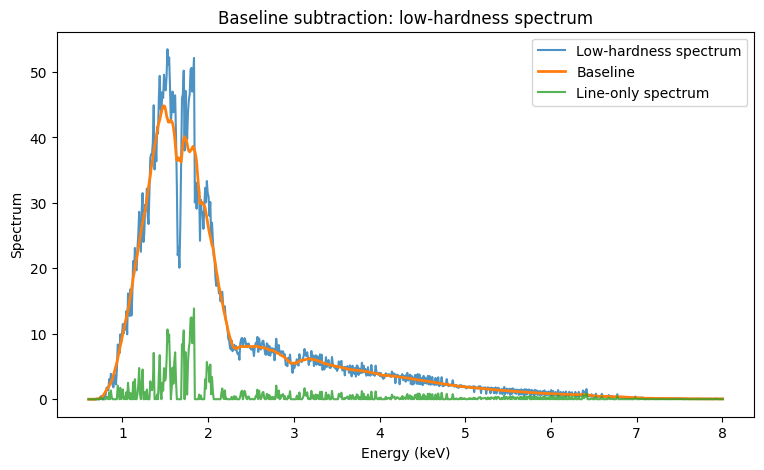

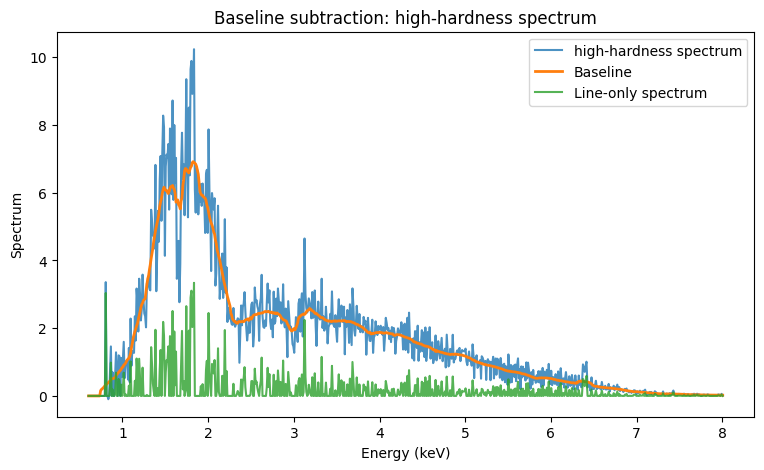

729
729


(None, None)

In [4]:
base_low = base_calculator(values_low)

if len(base_low) != len(values_low):
    raise ValueError("base_low and values_low have different lengths")

ylines_low = np.maximum(values_low - base_low, 0)

plt.figure(figsize=(9, 5))

plt.plot(energy_low, values_low, label="Low-hardness spectrum", alpha=0.8)
plt.plot(energy_low, base_low, label="Baseline", linewidth=2)
plt.plot(energy_low, ylines_low, label="Line-only spectrum", alpha=0.8)

plt.xlabel("Energy (keV)")
plt.ylabel("Spectrum")
plt.title("Baseline subtraction: low-hardness spectrum")
plt.legend()
plt.show()


base_high = base_calculator(values_high)

if len(base_high) != len(values_high):
    raise ValueError("base_low and values_low have different lengths")

ylines_high = np.maximum(values_high - base_high, 0)

plt.figure(figsize=(9, 5))

plt.plot(energy_high, values_high, label="high-hardness spectrum", alpha=0.8)
plt.plot(energy_high, base_high, label="Baseline", linewidth=2)
plt.plot(energy_high, ylines_high, label="Line-only spectrum", alpha=0.8)

plt.xlabel("Energy (keV)")
plt.ylabel("Spectrum")
plt.title("Baseline subtraction: high-hardness spectrum")
plt.legend()
plt.show()

print(len(energy_low)),print(len(energy_high
                                ))

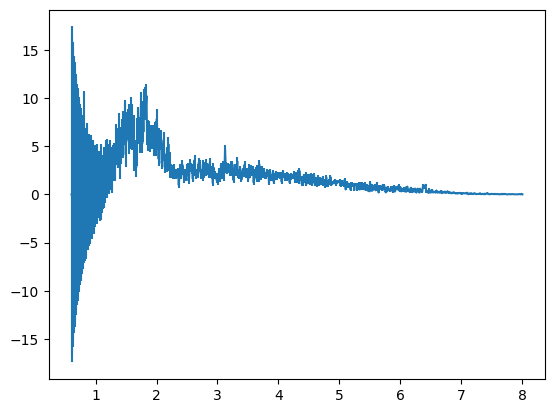

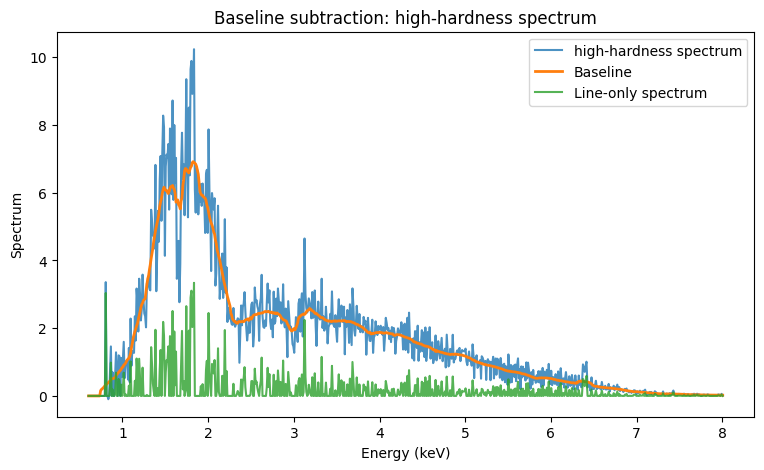

In [5]:
plt.errorbar(energy_high, values_high, yerr=errors_high)

base_high = base_calculator(values_high)
ylines_high = np.maximum(values_high - base_high, 0)

plt.figure(figsize=(9, 5))

plt.plot(energy_high, values_high, label="high-hardness spectrum", alpha=0.8)
plt.plot(energy_high, base_high, label="Baseline", linewidth=2)
plt.plot(energy_high, ylines_high, label="Line-only spectrum", alpha=0.8)

plt.xlabel("Energy (keV)")
plt.ylabel("Spectrum")
plt.title("Baseline subtraction: high-hardness spectrum")
plt.legend()
plt.show()

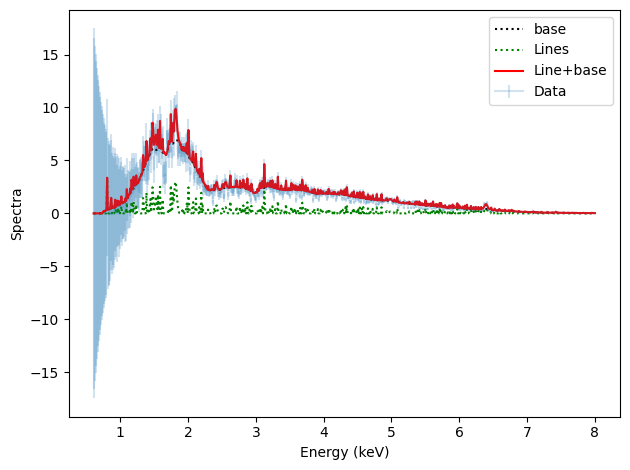

In [6]:
lines_high = find_emission_lines(
    energy_high,
    values_high,
    errors_high,
    en1=0.7,
    en2=8,
    show_plot=True,
    plot_name="xmm_bliss_fit.png"
)

Error fitting block 44: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Error fitting block 143: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Error fitting block 269: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Error fitting block 295: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Error fitting block 334: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Error fitting block 340: Optimal parameters not found: The maximum number of function evaluations is exceeded.


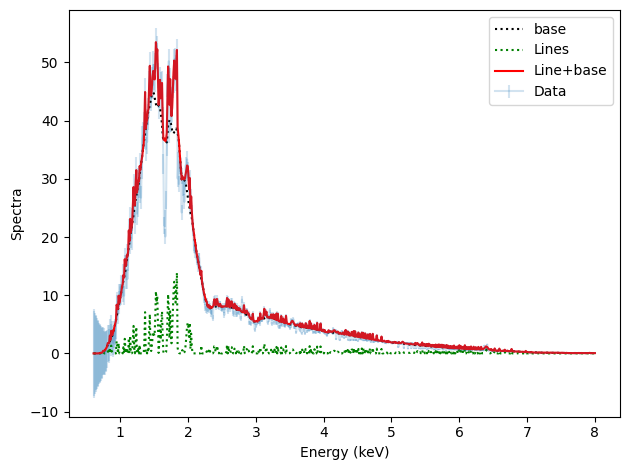

In [7]:
lines_low = find_emission_lines(
    energy_low,
    values_low,
    errors_low,
    en1=0.7,
    en2=8,
    show_plot=True,
    plot_name="xmm_bliss_fit.png"
)

In [8]:
clean_lines_low = lines_low[(lines_low.snr_area>0.1) & (lines_low.snr_peak>0.1)&(lines_low.sigma<0.1)]
#clean_lines_high = lines_high[(lines_high.snr_area>0.1) & (lines_high.snr_peak>0.1)&(lines_high.sigma<0.1)]

clean_lines_low = add_most_probable_ion(clean_lines_low,v_doppler_kms=1500)
#clean_lines_high = add_most_probable_ion(clean_lines_high,v_doppler_kms=1500)

<Figure size 537.871x500 with 0 Axes>

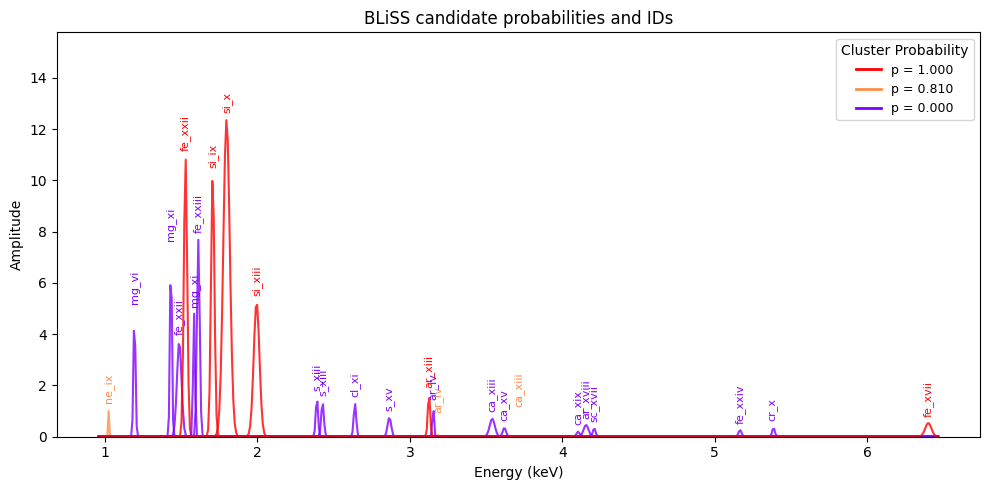

In [9]:

#fig, ax = plot_line_prob(clean_lines_high, show=False, size_fig=(10,5))
plt.show()
fig, ax = plot_line_prob(clean_lines_low, show=False, size_fig=(10,5))
ax.set_title("BLiSS candidate probabilities and IDs")
plt.show()

In [10]:
elow=1
ehigh=3

reg1low = clean_lines_low[(clean_lines_low.center>elow)&(clean_lines_low.center<ehigh)].reset_index(drop=True)
reg1high = clean_lines_high[(clean_lines_high.center>elow)&(clean_lines_high.center<ehigh)].reset_index(drop=True)

fig, ax = plot_line_prob(reg1high, show=False, size_fig=(10,5))

for i in range(len(high.energy_obs_keV)):
    ax.vlines(x=high.energy_obs_keV, ymin=0, ymax=10, color="k", linestyle=":")

NameError: name 'clean_lines_high' is not defined

In [ ]:
fig, ax = plot_line_prob(reg1low, show=False, size_fig=(10,5))

for i in range(len(low.energy_obs_keV)):
    ax.vlines(x=low.energy_obs_keV, ymin=0, ymax=70, color="k", linestyle="--")